# UMAP Grid: f / sw Sweep

Plots a 2-row grid of UMAP projections for runs sharing the same core
hyperparameters but varying **f** (label fraction) or **sw** (supervision weight).

- **Row 1** — vary f, sw fixed at anchor
- **Row 2** — vary sw, f fixed at anchor

Colour = interest score (human_label 1–4,  colormap).
UMAP coordinates are cached to  for fast reloads.

In [10]:
from pathlib import Path

OUTPUTS_ROOT = Path("/users/mbredber/p3_SUPLAT/outputs")

# ── Anchor hyperparameters (everything except f and sw) ──────────────────
RUN_GLOB_BASE = "byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw*_f*/seed2"

# Sweep axes — f=1 sw=0.05 is the anchor (exists in both rows)
F_VALS  = [0.1, 1]                      # row 1: vary f  (sw fixed at SW_ANCHOR)
SW_VALS = [0.0, 0.05, 0.1, 0.5, 1.0]   # row 2: vary sw (f  fixed at F_ANCHOR)
F_ANCHOR  = 1
SW_ANCHOR = 0.05

FEATURE_TYPE = "projections"   # "projections" or "encodings"

LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"

COLOUR_BY = "initial"   # "initial" | "interest"

# When True, drop the two smallest sw values in each sw-sweep figure (keeps 5 maps)
RESTRICT_TO_FIVE_MAPS = True

print("Config OK")

Config OK


In [11]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import umap as umap_lib

print("Imports OK")

Imports OK


In [12]:
# ── Label columns and tier scoring (matches rare_object_detection.ipynb) ──
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings",
           "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]
TIERS   = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2), (1, SCORE_1)]

# Initial classes (cols 0-4) + catch-all
INITIAL_NAMES = ["FRI", "FRII", "Hybrid", "Spiral", "Relaxed", "None or multiple"]

_labels_all = np.load(LABELS_NPY_PATH)   # (N_all, 20)


def build_human_labels(idx_arr: np.ndarray) -> np.ndarray:
    """Map global source indices → integer interest score 1–4."""
    ldf = pd.DataFrame(_labels_all[idx_arr].astype(bool), columns=LABEL_COLS)
    hl  = np.ones(len(ldf), dtype=int)
    for score_val, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = score_val
    return hl


def build_initial_labels(idx_arr: np.ndarray) -> np.ndarray:
    """Map global source indices → integer initial class 0–4, or 5 ('None or multiple').

    Sources with exactly one of the 5 initial labels get that class index.
    All others (unlabelled, multi-label, or non-initial) are mapped to 5.
    """
    init = _labels_all[idx_arr, 0:5].astype(bool)
    n_init = init.sum(axis=1)
    labels = np.full(len(idx_arr), 5, dtype=int)   # default: None or multiple
    for c in range(5):
        labels[(n_init == 1) & init[:, c]] = c
    return labels


def load_run(run_dir: Path, feature_type: str = "projections"):
    """Load all projections + global indices for a run (train + test).

    Handles f=0, 0<f<1, and f=1 robustly.
    Uses train_idx.npy (stable across all runs with same seed) as the
    authoritative training index list.  Shared labelled/unlabelled idx
    files are only trusted when their size matches the projection file.
    Returns (projections, idx_arr) or raises FileNotFoundError.
    """
    d = run_dir / "data"
    b = d / "byol"

    ckpt    = torch.load(run_dir / "byol_model_best.pt", map_location="cpu", weights_only=False)
    seed    = int(ckpt["config"]["data_seed"])
    f_label = float(ckpt["config"].get("f_label", 1.0))

    # Determine splits root: new layout has a seed subdir, old layout does not
    if re.match(r"seed\d+$", run_dir.name):
        s = run_dir.parent.parent.parent / "data_splits" / str(seed)
    else:
        s = run_dir.parent.parent / "data_splits" / str(seed)

    # Fraction suffix used in idx filenames (e.g. "1" or "0.1")
    f_str = str(int(f_label)) if f_label == int(f_label) else str(f_label)

    def _load_idx(name):
        p = s / name
        return np.load(p if p.exists() else d / name)

    # Stable indices — same for every run with the same seed
    train_idx_all = _load_idx("train_idx.npy")
    test_idx      = _load_idx("test_idx.npy")

    test_proj = np.load(b / f"test_{feature_type}.npy")
    lab_proj  = np.load(b / f"labelled_train_{feature_type}.npy")

    n_lab = len(lab_proj)
    n_all = len(train_idx_all)

    unlab_path = b / f"unlabelled_train_{feature_type}.npy"

    if f_label == 0.0 or n_lab == n_all:
        # f=0: train_extract_loader uses unlab_ds (all training), so lab_proj = ALL training.
        #       unlabelled_train file also exists but is identical data — skip to avoid doubling.
        # f=1: lab_proj also = ALL training, no unlabelled file.
        train_proj    = lab_proj
        train_idx_out = train_idx_all
    else:
        # Partial f (0 < f < 1): lab_proj has n_lab < n_all entries.
        # Try shared idx files (with fraction suffix); fall back to contiguous slice.
        try:
            lab_idx_shared = _load_idx(f"labelled_train_idx_f{f_str}.npy")
        except FileNotFoundError:
            lab_idx_shared = _load_idx("labelled_train_idx.npy")
        lab_idx = lab_idx_shared if len(lab_idx_shared) == n_lab else train_idx_all[:n_lab]

        if unlab_path.exists():
            unlab_proj = np.load(unlab_path)
            n_unlab = len(unlab_proj)
            try:
                unlab_idx_shared = _load_idx(f"unlabelled_train_idx_f{f_str}.npy")
            except FileNotFoundError:
                unlab_idx_shared = _load_idx("unlabelled_train_idx.npy")
            unlab_idx = (unlab_idx_shared if len(unlab_idx_shared) == n_unlab
                         else train_idx_all[n_lab:n_lab + n_unlab])
            train_proj    = np.concatenate([lab_proj, unlab_proj], axis=0)
            train_idx_out = np.concatenate([lab_idx, unlab_idx])
        else:
            train_proj    = lab_proj
            train_idx_out = lab_idx

    all_proj = np.concatenate([train_proj, test_proj], axis=0)
    all_idx  = np.concatenate([train_idx_out, test_idx])
    return all_proj, all_idx


def get_or_fit_umap(run_dir: Path, projections: np.ndarray,
                    feature_type: str = "projections") -> np.ndarray:
    """Return cached 2-D UMAP coords, or fit and cache them.

    Checks (in order):
      1. Parquet at <run_dir>/data/umap/umap_<feature_type>.parquet (from train_byol.py)
      2. .npy cache at <run_dir>/data/umap/umap_<feature_type>_coords.npy
      3. Fits UMAP and saves a .npy cache for future use.
    """
    n = projections.shape[0]
    umap_dir = run_dir / "data" / "umap"

    parquet = umap_dir / f"umap_{feature_type}.parquet"
    if parquet.exists():
        _df = pd.read_parquet(parquet, columns=["umap_x", "umap_y"])
        if len(_df) == n:
            return _df[["umap_x", "umap_y"]].values

    npy_cache = umap_dir / f"umap_{feature_type}_coords.npy"
    if npy_cache.exists():
        coords = np.load(npy_cache)
        if coords.shape[0] == n:
            return coords

    print(f"  fitting UMAP ({n} sources, dim={projections.shape[1]})...",
          flush=True)
    reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1,
                            metric="euclidean", random_state=42)
    coords = reducer.fit_transform(projections)
    umap_dir.mkdir(parents=True, exist_ok=True)
    np.save(npy_cache, coords)
    return coords


print("Helpers defined")

Helpers defined


In [13]:
# ── Discover all matching runs, keep seed2 (or latest seed) per (f, sw) ──
all_matches = sorted(OUTPUTS_ROOT.glob(RUN_GLOB_BASE))

run_map = {}   # (f, sw) -> run_dir
for rd in all_matches:
    # For seed-subdir layout the hyperparams are in the parent dir name
    name_to_parse = rd.parent.name if re.match(r"seed\d+$", rd.name) else rd.name
    # New naming: _sw{sw}_f{f}  (sw before f, no timestamp)
    m = re.search(r"_sw([\d.]+)_f([\d.]+)", name_to_parse)
    if m:
        key = (float(m.group(2)), float(m.group(1)))   # (f, sw)
    else:
        # Fall back to old naming: _f{f}_sw{sw}_timestamp
        m = re.search(r"_f([\d.]+)_sw([\d.]+)", name_to_parse)
        if not m:
            continue
        key = (float(m.group(1)), float(m.group(2)))
    run_map[key] = rd   # sorted → latest seed wins

print(f"Found {len(run_map)} unique (f, sw) combinations:")
for (f, sw), rd in sorted(run_map.items()):
    print(f"  f={f}  sw={sw}  →  {rd}")

Found 10 unique (f, sw) combinations:
  f=0.1  sw=0.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1/seed2
  f=0.1  sw=0.05  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1/seed2
  f=0.1  sw=0.1  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1/seed2
  f=0.1  sw=0.5  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1/seed2
  f=0.1  sw=1.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw1.0_f0.1/seed2
  f=1.0  sw=0.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/seed2
  f=1.0  sw=0.05  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/seed2
  f=1.0  sw=0.1  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1/seed2
  f=1.0  sw=0.5  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3

In [14]:
# ── Load projections and fit/load UMAP for every discovered run ──────────
run_data = {}   # (f, sw) -> dict(coords, human_labels, initial_labels)

for key, rd in sorted(run_map.items()):
    f, sw = key
    print(f"[f={f}  sw={sw}]  {rd.name}", flush=True)
    try:
        proj, idx = load_run(rd, FEATURE_TYPE)
        coords    = get_or_fit_umap(rd, proj, FEATURE_TYPE)
        run_data[key] = dict(
            coords         = coords,
            human_labels   = build_human_labels(idx),
            initial_labels = build_initial_labels(idx),
            run_dir        = rd,
        )
        print(f"  → {proj.shape[0]} sources, UMAP shape {coords.shape}")
    except FileNotFoundError as e:
        print(f"  ✗ skipping: {e}")

print(f"Loaded {len(run_data)} runs.")

[f=0.1  sw=0.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.05]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.1]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.5]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=1.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.05]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.1]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.5]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=1.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
Loaded 10 runs.


Saved → /users/mbredber/p3_SUPLAT/outputs/figures/umaps_plotting/umap_grid_initial.png


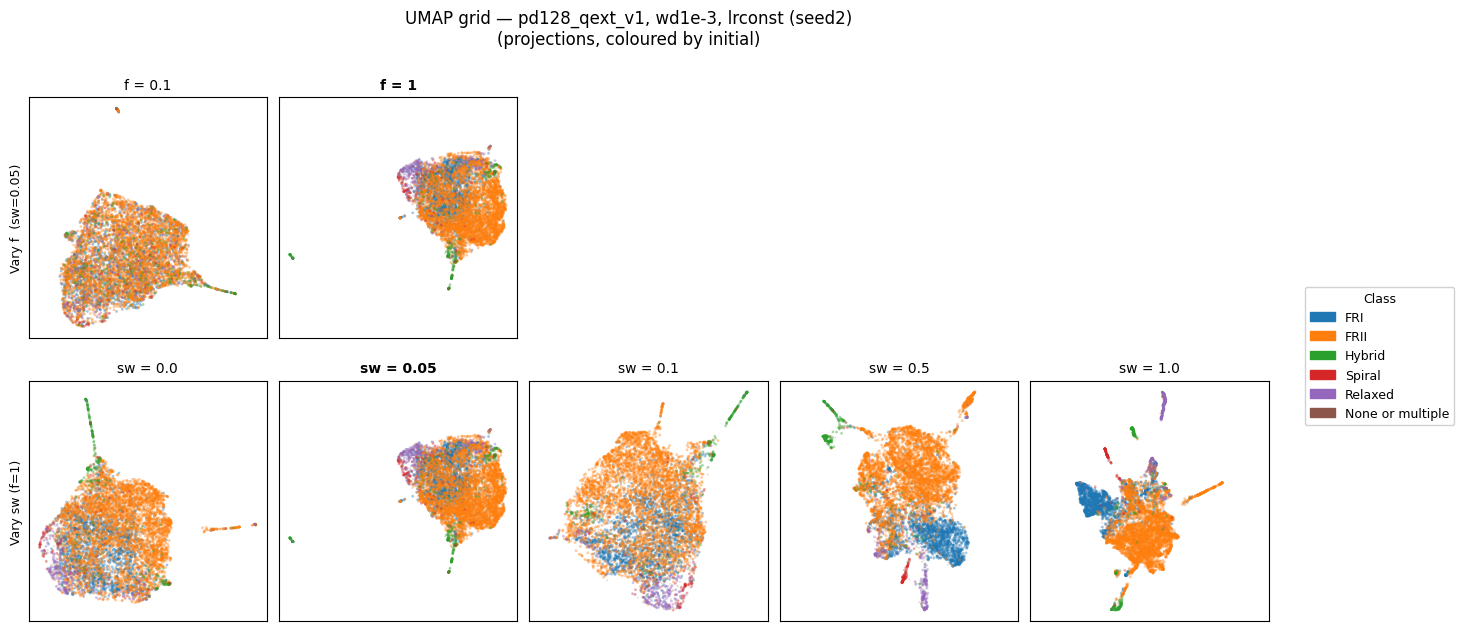

In [15]:
# ── Build two-row grid ───────────────────────────────────────────────────
#   Row 0: vary f  (sw = SW_ANCHOR)
#   Row 1: vary sw (f  = F_ANCHOR)

row0_keys = [(f,  SW_ANCHOR) for f  in F_VALS]
row1_keys = [(F_ANCHOR, sw)  for sw in SW_VALS]

n_cols = max(len(row0_keys), len(row1_keys))
fig, axes = plt.subplots(
    2, n_cols,
    figsize=(3.2 * n_cols, 6.8),
    gridspec_kw={"wspace": 0.05, "hspace": 0.18},
)

row_labels = [
    f"Vary f  (sw={SW_ANCHOR})",
    f"Vary sw (f={F_ANCHOR})",
]

# ── Colour scheme ─────────────────────────────────────────────────────────
if COLOUR_BY == "interest":
    _cmap   = plt.cm.plasma
    _norm   = mcolors.Normalize(vmin=1, vmax=4)
    _vals   = [1, 2, 3, 4]          # plot order: 4 (rare) rendered last / on top
    _lkey   = "human_labels"
else:  # "initial"
    _cmap   = plt.cm.tab10
    _norm   = mcolors.Normalize(vmin=0, vmax=9)   # tab10 has 10 slots
    _vals   = [5, 0, 1, 2, 3, 4]   # "Other" behind, named classes on top
    _lkey   = "initial_labels"

for row_idx, row_keys in enumerate([row0_keys, row1_keys]):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        ax.set_xticks([])
        ax.set_yticks([])

        if col_idx >= len(row_keys):
            ax.axis("off")
            continue

        key = row_keys[col_idx]
        f_val, sw_val = key

        if key not in run_data:
            ax.text(0.5, 0.5, f"f={f_val}\nsw={sw_val}\n(missing)",
                    ha="center", va="center", fontsize=9,
                    transform=ax.transAxes, color="#888")
            ax.set_facecolor("#f5f5f5")
            continue

        d      = run_data[key]
        coords = d["coords"]
        labels = d[_lkey]

        for val in _vals:
            mask = labels == val
            if not mask.any():
                continue
            if COLOUR_BY == "interest":
                s, alpha = (6, 0.6) if val == 4 else (3, 0.3)
            else:
                s, alpha = (2, 0.2) if val == 5 else (4, 0.4)
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                c=[_cmap(_norm(val))] * mask.sum(),
                s=s, alpha=alpha, linewidths=0, rasterized=True,
            )

        ax.set_aspect("equal", adjustable="datalim")

        if row_idx == 0:
            title = f"f = {f_val}"
        else:
            title = f"sw = {sw_val}"
        is_anchor = (f_val == F_ANCHOR and sw_val == SW_ANCHOR)
        ax.set_title(title, fontsize=10,
                     fontweight="bold" if is_anchor else "normal")

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=9, labelpad=4)

# ── Legend / colorbar ─────────────────────────────────────────────────────
if COLOUR_BY == "interest":
    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.01, aspect=40)
    cbar.set_label("Interest score", fontsize=10)
    cbar.set_ticks([1, 2, 3, 4])
    cbar.set_ticklabels(["1 (common)", "2", "3", "4 (rare)"])
else:
    handles = [
        mpatches.Patch(color=_cmap(_norm(i)), label=name)
        for i, name in enumerate(INITIAL_NAMES)
    ]
    fig.legend(handles=handles, loc="center right", fontsize=9,
               bbox_to_anchor=(1.02, 0.5), title="Class", title_fontsize=9,
               framealpha=0.9)

fig.suptitle(
    f"UMAP grid — pd128_qext_v1, wd1e-3, lrconst (seed2)\n"
    f"({FEATURE_TYPE}, coloured by {COLOUR_BY})",
    fontsize=12, y=1.01,
)

out_path = Path("/users/mbredber/p3_SUPLAT/outputs/figures/umaps_plotting") / f"umap_grid_{COLOUR_BY}.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## sw Sweep — single reference run

Vary `sw` with all other hyperparameters fixed to those of a chosen reference run.
Discovers sibling runs by replacing the `sw` value with a wildcard in the run name.

In [16]:
SW_SWEEP_REF = Path("/users/mbredber/p3_SUPLAT/outputs/byol_runs/"
                    "enb0_none_pond_lrconst_wd1e-4_lfull_ema0.99_vicregvar0_cov0_gamma1.0_f1_sw10_20260605_1148")

(stem, f) groups with ≥3 sw variants:
  f=0.1  pd128_qext_v1_wd1e-3_lrconst_sw*_f0.1
    sw values: [0.0, 0.05, 0.1, 0.5, 1.0]
  f=1.0  pd128_qext_v1_wd1e-3_lrconst_sw*_f1
    sw values: [0.0, 0.05, 0.1, 0.5, 1.0]

── f=0.1  pd128_qext_v1_wd1e-3_lrconst_sw*_f0.1 ──
  sw=0.0  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.05  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.1  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.5  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=1.0  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw1.0_f0.1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  Saved → /users/mbredber/p

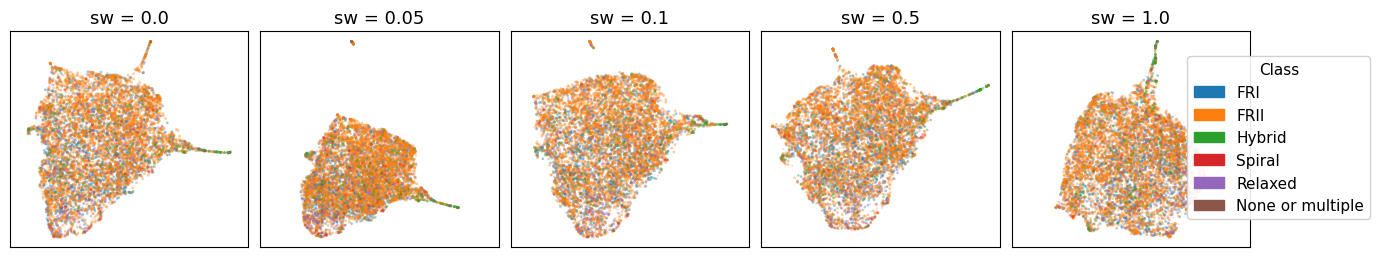


── f=1.0  pd128_qext_v1_wd1e-3_lrconst_sw*_f1 ──
  sw=0.0  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.05  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.1  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=0.5  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  sw=1.0  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw1.0_f1/seed2
    → 7596 sources, UMAP shape (7596, 2)
  Saved → /users/mbredber/p3_SUPLAT/outputs/figures/umaps_plotting/umap_sw_sweep_pd128_qext_v1_wd1e-3_lrconst_swX_f1_f1.0_initial.png


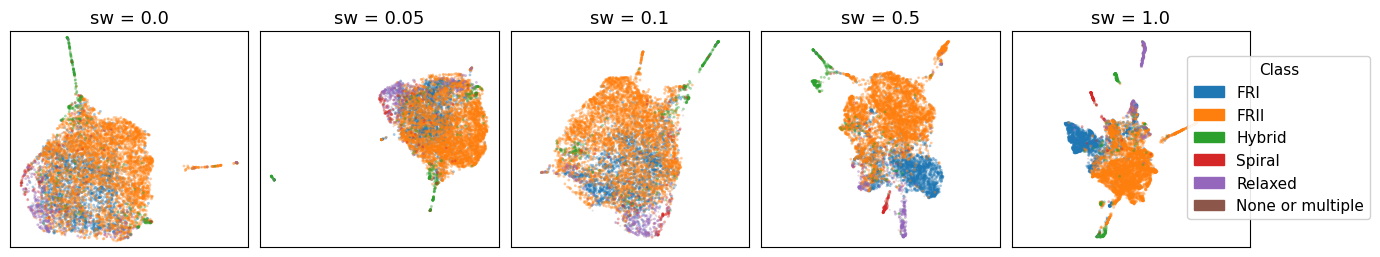

In [17]:
# ── Discover all unique (stem, f) combinations and plot sw sweep for each ─
# A "stem" groups runs sharing all hyperparameters except sw and timestamp.
# One sw-sweep figure is produced per (stem, f-value) combination,
# but only when there are ≥3 distinct sw values for that group.

def _sw_stem_key(run_name: str):
    """Return (stem_glob, f_val) for a run directory name (parent dir, not seed subdir)."""
    s = re.sub(r"_\d{8}_\d{4}$", "", run_name)   # strip timestamp if present
    m_f = re.search(r"_f([\d.]+)(?:_|$)", s)
    f_val = float(m_f.group(1)) if m_f else None
    stem  = re.sub(r"_sw[\d.]+_", "_sw*_", s)     # wildcard sw
    return stem, f_val

# Scan byol_runs — support both new layout (parent/seed*) and old (run_*)
_byol_runs = OUTPUTS_ROOT / "byol_runs"
_stem_f_groups = {}   # (stem, f_val) -> [run_dir, ...]  (sorted = latest last)

for rd in sorted(_byol_runs.glob("pd128_qext_v1_*/seed2")):
    if not rd.is_dir():
        continue
    name_to_parse = rd.parent.name   # hyperparams are in the parent dir name
    if not re.search(r"_sw[\d.]+", name_to_parse):
        continue
    stem, f_val = _sw_stem_key(name_to_parse)
    if f_val is None:
        continue
    _stem_f_groups.setdefault((stem, f_val), []).append(rd)

# Also scan old-style run_* directories directly under byol_runs
for rd in sorted(_byol_runs.glob("run_*")):
    if not rd.is_dir():
        continue
    if not re.search(r"_sw[\d.]+_", rd.name + "_"):
        continue
    stem, f_val = _sw_stem_key(rd.name)
    if f_val is None:
        continue
    _stem_f_groups.setdefault((stem, f_val), []).append(rd)

# Report groups with ≥3 sw values
print("(stem, f) groups with ≥3 sw variants:")
for (stem, f_val), runs in sorted(_stem_f_groups.items()):
    sw_vals = sorted({
        float(re.search(r"_sw([\d.]+)", (r.parent.name if re.match(r"seed\d+$", r.name) else r.name) + "_").group(1))
        for r in runs
    })
    if len(sw_vals) >= 3:
        print(f"  f={f_val}  {stem}")
        print(f"    sw values: {sw_vals}")

# ── Colour scheme (shared across all figures) ─────────────────────────────
if COLOUR_BY == "interest":
    _cmap2 = plt.cm.plasma
    _norm2 = mcolors.Normalize(vmin=1, vmax=4)
    _vals2 = [1, 2, 3, 4]
    _lkey2 = "human_labels"
else:
    _cmap2 = plt.cm.tab10
    _norm2 = mcolors.Normalize(vmin=0, vmax=9)
    _vals2 = [5, 0, 1, 2, 3, 4]   # None or multiple behind, named classes on top
    _lkey2 = "initial_labels"

_fig_dir = Path("/users/mbredber/p3_SUPLAT/outputs/figures/umaps_plotting")

# ── One figure per (stem, f) group with ≥3 sw variants ───────────────────
for (stem, f_val), stem_runs in sorted(_stem_f_groups.items()):
    # Keep latest run per sw value (list is sorted, so last entry wins)
    sw_run_map = {}
    for rd in stem_runs:
        name_to_parse = rd.parent.name if re.match(r"seed\d+$", rd.name) else rd.name
        m = re.search(r"_sw([\d.]+)", name_to_parse + "_")
        if m:
            sw_run_map[float(m.group(1))] = rd

    if len(sw_run_map) < 3:
        continue

    _sw_data = {}
    print(f"\n── f={f_val}  {stem} ──")
    for sw_val, rd in sorted(sw_run_map.items()):
        print(f"  sw={sw_val}  {rd}", flush=True)
        try:
            proj, idx = load_run(rd, FEATURE_TYPE)
            coords    = get_or_fit_umap(rd, proj, FEATURE_TYPE)
            _sw_data[sw_val] = dict(
                coords         = coords,
                human_labels   = build_human_labels(idx),
                initial_labels = build_initial_labels(idx),
            )
            print(f"    → {proj.shape[0]} sources, UMAP shape {coords.shape}")
        except FileNotFoundError as e:
            print(f"    ✗ skipping: {e}")

    _sw_vals_found = sorted(_sw_data.keys())
    if RESTRICT_TO_FIVE_MAPS and len(_sw_vals_found) > 5:
        _sw_vals_found = _sw_vals_found[len(_sw_vals_found) - 5:]

    n = len(_sw_vals_found)
    if n == 0:
        print("  Nothing to plot.")
        continue

    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 2.8),
                             gridspec_kw={"wspace": 0.05})
    if n == 1:
        axes = [axes]

    for ci, sw_val in enumerate(_sw_vals_found):
        ax = axes[ci]
        ax.set_xticks([]); ax.set_yticks([])
        d      = _sw_data[sw_val]
        coords = d["coords"]
        labels = d[_lkey2]

        for val in _vals2:
            mask = labels == val
            if not mask.any():
                continue
            if COLOUR_BY == "interest":
                s, alpha = (6, 0.6) if val == 4 else (3, 0.3)
            else:
                s, alpha = (2, 0.2) if val == 5 else (4, 0.4)
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[_cmap2(_norm2(val))] * mask.sum(),
                       s=s, alpha=alpha, linewidths=0, rasterized=True)

        ax.set_aspect("equal", adjustable="datalim")
        ax.set_title(f"sw = {sw_val}", fontsize=13)

    if COLOUR_BY == "interest":
        sm = plt.cm.ScalarMappable(cmap=_cmap2, norm=_norm2)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01, aspect=30)
        cbar.set_label("Interest score", fontsize=12)
        cbar.set_ticks([1, 2, 3, 4])
        cbar.set_ticklabels(["1 (common)", "2", "3", "4 (rare)"], fontsize=11)
    else:
        _handles2 = [mpatches.Patch(color=_cmap2(_norm2(i)), label=name)
                     for i, name in enumerate(INITIAL_NAMES)]
        fig.legend(handles=_handles2, loc="center right", fontsize=11,
                   bbox_to_anchor=(0.98, 0.5), title="Class", title_fontsize=11,
                   framealpha=0.9)

    _safe = re.sub(r"[*]", "X", f"{stem}_f{f_val}")
    _out  = _fig_dir / f"umap_sw_sweep_{_safe}_{COLOUR_BY}.png"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_out, dpi=150, bbox_inches="tight")
    print(f"  Saved → {_out}")
    plt.show()

## Regenerate figures from parquet

Reads `data/umap/umap_encodings.parquet` and `data/umap/umap_projections.parquet` from a
single run directory and reproduces all standard UMAP figures without re-fitting or
loading raw projections.

Set `REGEN_RUN_DIR` to the run you want to plot.

In [18]:
REGEN_RUN_DIR = Path("/users/mbredber/p3_SUPLAT/outputs/byol_runs/"
                     "pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/seed2")

# ── Load parquets ─────────────────────────────────────────────────────────────
_umap_dir  = REGEN_RUN_DIR / "data" / "umap"
_fig_dir   = REGEN_RUN_DIR / "figures" / "umap"
_fig_dir.mkdir(parents=True, exist_ok=True)

_enc_path  = _umap_dir / "umap_encodings.parquet"
_proj_path = _umap_dir / "umap_projections.parquet"

if not _enc_path.exists() or not _proj_path.exists():
    raise FileNotFoundError(
        f"Parquet files not found in {_umap_dir}.\n"
        f"  encodings:   {_enc_path.exists()}\n"
        f"  projections: {_proj_path.exists()}"
    )

_enc_df  = pd.read_parquet(_enc_path)
_proj_df = pd.read_parquet(_proj_path)
print(f"Encodings:   {len(_enc_df)} rows, columns: {list(_enc_df.columns)}")
print(f"Projections: {len(_proj_df)} rows")

_enc_xy   = _enc_df[["umap_x", "umap_y"]].values
_proj_xy  = _proj_df[["umap_x", "umap_y"]].values
_lf       = _enc_df[LABEL_COLS].values.astype(np.int64)   # (N, 20)
_split    = _enc_df["split"].values
_pxsum    = _enc_df["pixel_sum"].values
_interest = _enc_df["interest_score"].values.astype(float)


# ── Colour helpers ─────────────────────────────────────────────────────────────
INITIAL_COLORS = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]
INITIAL_NAMES_5 = ["FRI", "FRII", "Hybrids", "Spirals", "Relaxed doubles"]
SPLIT_COLORS = {"unlabelled_train": ("#aaaaaa", 0.3),
                "labelled_train":   ("#2196F3", 0.7),
                "test":             ("#9C27B0", 0.7)}


def _save(fig, name):
    p = _fig_dir / name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved {p.name}")


# ── 1. Encodings — initial class ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
_init = _lf[:, 0:5]
_pure = _init.sum(axis=1) == 1
for c, (col, name) in enumerate(zip(INITIAL_COLORS, INITIAL_NAMES_5)):
    m = _pure & (_init[:, c] == 1)
    if m.any():
        ax.scatter(_enc_xy[m, 0], _enc_xy[m, 1], c=col, s=4, alpha=0.5,
                   label=f"{name} ({m.sum()})", linewidths=0)
_multi = ~_pure
ax.scatter(_enc_xy[_multi, 0], _enc_xy[_multi, 1], c="#cccccc", s=2, alpha=0.2,
           label=f"multi/none ({_multi.sum()})", linewidths=0, zorder=0)
ax.set_title(f"Encodings — initial ({len(_enc_df)} sources)")
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
_save(fig, "umap_all_initial.png")

# ── 2. Projections — initial class ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for c, (col, name) in enumerate(zip(INITIAL_COLORS, INITIAL_NAMES_5)):
    m = _pure & (_init[:, c] == 1)
    if m.any():
        ax.scatter(_proj_xy[m, 0], _proj_xy[m, 1], c=col, s=4, alpha=0.5,
                   label=f"{name} ({m.sum()})", linewidths=0)
ax.scatter(_proj_xy[_multi, 0], _proj_xy[_multi, 1], c="#cccccc", s=2, alpha=0.2,
           label=f"multi/none ({_multi.sum()})", linewidths=0, zorder=0)
ax.set_title(f"Projections — initial ({len(_proj_df)} sources)")
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
_save(fig, "umap_proj_initial.png")

# ── 3. Encodings — train / test split ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for split_val, (col, alpha) in SPLIT_COLORS.items():
    m = _split == split_val
    if m.any():
        ax.scatter(_enc_xy[m, 0], _enc_xy[m, 1], c=col, s=4, alpha=alpha,
                   label=f"{split_val} ({m.sum()})", linewidths=0)
ax.set_title(f"Encodings — split ({len(_enc_df)} sources)")
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
_save(fig, "umap_all_train_labelled.png")

# ── 4. Encodings — brightness (pixel sum) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(_enc_xy[:, 0], _enc_xy[:, 1], c=_pxsum, s=3, alpha=0.4,
                cmap="plasma", linewidths=0)
plt.colorbar(sc, ax=ax, label="Total pixel sum")
ax.set_title(f"Encodings — brightness ({len(_enc_df)} sources)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
_save(fig, "umap_all_brightness.png")

# ── 5. Encodings — interest score ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(_enc_xy[:, 0], _enc_xy[:, 1], c=_interest, s=3, alpha=0.4,
                cmap="plasma", vmin=1, vmax=4, linewidths=0)
cb = plt.colorbar(sc, ax=ax, label="Interest score", ticks=[1, 2, 3, 4])
ax.set_title(f"Encodings — interest score ({len(_enc_df)} sources)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
_save(fig, "umap_all_interest.png")

print(f"\nAll figures saved to {_fig_dir}/")

Encodings:   7596 rows, columns: ['split', 'fri', 'frii', 'hybrid', 'spiral', 'relaxed', 'cshaped', 'sshaped', 'misaligned', 'wings', 'xshaped', 'straight', 'multihotspots', 'continuous', 'banding', 'onesided', 'restarted', 'cluster', 'merger', 'diffuse', 'unknown', 'pixel_sum', 'interest_score', 'umap_x', 'umap_y']
Projections: 7596 rows
  Saved umap_all_initial.png
  Saved umap_proj_initial.png
  Saved umap_all_train_labelled.png
  Saved umap_all_brightness.png
  Saved umap_all_interest.png

All figures saved to /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/seed2/figures/umap/
